# NP2 channel-map geometry checker (`channel_positions.npy`)

This notebook helps you verify that each probe's Kilosort geometry matches the channel map you intended to use.

It will:
- load `channel_positions.npy` (and optionally `channel_map.npy`),
- plot the physical channel layout,
- summarize x/y spacing statistics,
- estimate a **suggested** `nChannelsIsoDist` range for BombCell.


In [1]:
from pathlib import Path
import re
from typing import Any, Dict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams['figure.dpi'] = 120

## 1) Configure your Kilosort folders

Set one folder per probe (A/C/D etc.). Each folder should contain `channel_positions.npy`.


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import bombcell as bc

analysis_dir = Path.cwd().resolve()
sys.path.insert(0, str(analysis_dir))
from post_analysis_setup import load_post_analysis_context

CONFIG_FILE = r'C:\Users\user\Documents\github\bombcell\py_bombcell\grant\configs\grant_recording_config_reach15_20260201_session007.json'
RUN_MODE = 'batch'   # batch | single_probe | np20_rerun
TARGET_PROBE = 'B'   # A-F
TARGET_PROBES = ["A", "B", "C", "D", "E", "F"]   # A-F

✅ ipywidgets available - interactive GUI ready


In [3]:
ctx = load_post_analysis_context(CONFIG_FILE)
mode_to_roots = {
    'batch': (ctx['DEFAULT_KS_STAGING_ROOT'], ''),
    'np20_rerun': (ctx['NP20_KS_STAGING_ROOT'], ''),
    'single_probe': (ctx['BOMBCELL_KS_SINGLEPROBE_STAGING_ROOT'], ''),
}

# staging_root, save_subdir = mode_to_roots[RUN_MODE]
staging_root = r'H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618'
ks_dir = Path(staging_root) / f'kilosort4_{TARGET_PROBE}'
save_path = ks_dir / 'bombcell'

print('ks_dir:', ks_dir)
print('save_path:', save_path)

# load all ks_dir / bombcell results for selected probes and place in probe_dirs
if RUN_MODE == 'batch':
    probe_letters = list(ctx.get('PROBES_ALL', TARGET_PROBES))
else:
    probe_letters = [TARGET_PROBE]

probe_dirs = {}
missing_probes = []
for probe in probe_letters:
    ks_dir = Path(staging_root) / f'kilosort4_{probe}'
    save_path = ks_dir
    probe_dirs[probe] = save_path
    print(f'Loading probe {probe} from ks_dir: {ks_dir}')
    if not save_path.exists():
        print(f'Missing bombcell save_path for probe {probe}: {save_path}')
        missing_probes.append(probe)
        continue
probe_dirs

ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_B
save_path: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_B\bombcell
Loading probe A from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_A
Loading probe B from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_B
Loading probe C from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_C
Loading probe D from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20

{'A': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/bombcell/bombcell_batch_20260222_1618/kilosort4_A'),
 'B': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/bombcell/bombcell_batch_20260222_1618/kilosort4_B'),
 'C': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/bombcell/bombcell_batch_20260222_1618/kilosort4_C'),
 'D': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/bombcell/bombcell_batch_20260222_1618/kilosort4_D'),
 'E': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/bombcell/bombcell_batch_20260222_1618/kilosort4_E'),
 'F': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260201_session0

## 2) Helpers

In [4]:
def load_geometry(ks_dir: Path):
    ks_dir = Path(ks_dir)
    pos = np.load(ks_dir / "channel_positions.npy")

    cmap_file = ks_dir / "channel_map.npy"
    if cmap_file.exists():
        cmap = np.load(cmap_file).squeeze()
    else:
        cmap = None

    if pos.ndim != 2 or pos.shape[1] != 2:
        raise ValueError(f"Expected (n_channels,2) channel_positions in {ks_dir}, got {pos.shape}")

    return pos, cmap


def nearest_neighbor_distances(channel_positions):
    cp = np.asarray(channel_positions, dtype=float)
    d = cp[:, None, :] - cp[None, :, :]
    dist = np.sqrt((d**2).sum(axis=2))
    np.fill_diagonal(dist, np.inf)
    return dist.min(axis=1)


def summarize_geometry(channel_positions):
    cp = np.asarray(channel_positions, dtype=float)
    ux = np.unique(np.round(cp[:, 0], 6))
    uy = np.unique(np.round(cp[:, 1], 6))

    dx = np.diff(np.sort(ux)) if ux.size > 1 else np.array([])
    dy = np.diff(np.sort(uy)) if uy.size > 1 else np.array([])
    nn = nearest_neighbor_distances(cp)

    summary = {
        "n_channels": cp.shape[0],
        "n_unique_x": int(ux.size),
        "n_unique_y": int(uy.size),
        "median_dx": float(np.median(dx)) if dx.size else np.nan,
        "median_dy": float(np.median(dy)) if dy.size else np.nan,
        "median_nn_dist": float(np.median(nn)),
        "p90_nn_dist": float(np.percentile(nn, 90)),
    }
    return summary, nn


def suggest_nChannelsIsoDist(summary):
    """
    Heuristic suggestion:
    - sparse maps (large nearest-neighbor spacing) -> larger neighborhood
    - dense maps -> default is often fine
    """
    p90 = summary["p90_nn_dist"]
    if np.isnan(p90):
        return "unknown", "Could not estimate spacing"
    if p90 >= 40:
        return "8-12", "Sparse/interleaved geometry: use more nearby channels"
    if p90 >= 25:
        return "6-8", "Moderately sparse geometry: consider increasing from default 4"
    return "4-6", "Dense geometry: default 4 is usually reasonable"


def plot_geometry(channel_positions, title=""):
    cp = np.asarray(channel_positions)
    fig, ax = plt.subplots(figsize=(5, 9))
    ax.scatter(cp[:, 0], cp[:, 1], s=14)
    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    ax.set_aspect('equal')
    plt.show()


def compute_tip_distance_um(y_values, shank_y, tip_position: str = "max_y"):
    """Mirror the tip-distance logic used in run_bombcell_unified.py."""
    y_values = np.asarray(y_values, dtype=float)
    shank_y = np.asarray(shank_y, dtype=float)

    if tip_position == "min_y":
        return y_values - float(np.nanmin(shank_y))
    if tip_position == "max_y":
        return float(np.nanmax(shank_y)) - y_values
    raise ValueError("tip_position must be 'min_y' or 'max_y'.")


def region_to_label_suffix(region_name, fallback: str = "BRAINREGION") -> str:
    if region_name is None:
        return fallback

    text = str(region_name).strip()
    if not text:
        return fallback

    # Prefer abbreviation inside parentheses, e.g. "(... STIM)" -> "STIM".
    match = re.search(r"\(([^)]+)\)", text)
    token = match.group(1) if match else text
    suffix = re.sub(r"[^A-Za-z0-9]+", "_", token).strip("_").upper()
    return suffix if suffix else fallback


def _estimate_spacing(values, default_value: float) -> float:
    vals = np.unique(np.round(np.asarray(values, dtype=float), 6))
    if vals.size < 2:
        return float(default_value)

    diffs = np.diff(np.sort(vals))
    diffs = diffs[diffs > 0]
    if diffs.size == 0:
        return float(default_value)
    return float(np.median(diffs))


# Brain-region logic mirrored from add_brain_region_to_phy.ipynb
PROBE_A_REGION_RANGES_UM = {
    "IP": (0.0, 650.0),
    "SIM": (900.0, 3250.0),
}
PROBE_TO_REGION_ALIAS = {
    "B": "PG",
    "C": "MoP",
    "D": "VaL",
    "E": "SnR",
    "F": "RN",
}
REGION_BAND_COLORS = {
    "IP": "#4C78A8",
    "SIM": "#F58518",
    "PG": "#54A24B",
    "MOP": "#E45756",
    "VAL": "#72B7B2",
    "SNR": "#EECA3B",
    "RN": "#B279A2",
}


def _resolve_region_alias(probe_letter: str, probe_brain_regions: Dict[str, str]):
    if probe_letter in PROBE_TO_REGION_ALIAS:
        return PROBE_TO_REGION_ALIAS[probe_letter]

    region_name = probe_brain_regions.get(probe_letter)
    return region_to_label_suffix(region_name)


def get_brain_region_depth_bands(
    probe_letter: str,
    roi_end_um: float,
    probe_brain_regions: Dict[str, str],
):
    bands = []
    roi_end_um = float(roi_end_um)

    if probe_letter == "A":
        for region_name, (start_um, end_um) in PROBE_A_REGION_RANGES_UM.items():
            start_um = max(0.0, float(start_um))
            end_um = min(float(end_um), roi_end_um)
            if end_um >= start_um:
                bands.append(
                    {
                        "region": region_name,
                        "start_um": start_um,
                        "end_um": end_um,
                    }
                )
    else:
        region_name = _resolve_region_alias(probe_letter, probe_brain_regions)
        bands.append(
            {
                "region": region_name,
                "start_um": 0.0,
                "end_um": roi_end_um,
            }
        )

    return bands


def compute_channel_roi_region_labels(
    channel_positions,
    probe_letter: str,
    roi_end_um: float,
    tip_position: str = "max_y",
    out_label: str = "OUT_ROI",
    probe_brain_regions: Dict[str, str] = None,
):
    cp = np.asarray(channel_positions, dtype=float)
    if cp.ndim != 2 or cp.shape[1] != 2:
        raise ValueError(f"Expected (n_channels,2) channel_positions, got {cp.shape}")

    if probe_brain_regions is None:
        probe_brain_regions = {}

    shank_y = cp[:, 1].astype(float)
    depth_um = compute_tip_distance_um(shank_y, shank_y, tip_position=tip_position)
    in_roi_mask = depth_um <= float(roi_end_um)

    region_labels = np.full(cp.shape[0], "", dtype=object)
    region_bands = get_brain_region_depth_bands(
        probe_letter=probe_letter,
        roi_end_um=roi_end_um,
        probe_brain_regions=probe_brain_regions,
    )
    for band in region_bands:
        in_region = (
            in_roi_mask
            & (depth_um >= float(band["start_um"]))
            & (depth_um <= float(band["end_um"]))
        )
        region_labels[in_region] = str(band["region"])

    roi_labels = np.full(cp.shape[0], out_label, dtype=object)
    in_idx = np.where(in_roi_mask)[0]
    for idx in in_idx:
        region = str(region_labels[idx]).strip()
        if region:
            roi_labels[idx] = f"IN_ROI_{region.upper()}"
        else:
            roi_labels[idx] = "IN_ROI_UNASSIGNED"

    return {
        "depth_um": depth_um,
        "in_roi_mask": in_roi_mask,
        "region_labels": region_labels,
        "roi_labels": roi_labels,
        "region_bands": region_bands,
    }


def _region_band_color(region_name: str):
    key = str(region_name).upper()
    return REGION_BAND_COLORS.get(key, "#7F7F7F")


def plot_roi_channel_comparison(
    channel_positions,
    probe_letter: str,
    roi_end_um: float,
    out_label: str = "OUT_ROI",
    probe_brain_regions: Dict[str, str] = None,
):
    cp = np.asarray(channel_positions, dtype=float)
    x_um = cp[:, 0].astype(float)

    if probe_brain_regions is None:
        probe_brain_regions = {}

    x_spacing = _estimate_spacing(x_um, default_value=16.0)
    y_spacing = _estimate_spacing(cp[:, 1], default_value=15.0)
    box_w = max(8.0, 1.6 * x_spacing)
    box_h = max(8.0, 1.6 * y_spacing)
    x_pad = max(40.0, 3.0 * x_spacing)
    x_text = float(np.nanmax(x_um) + 0.55 * x_pad)

    fig, axes = plt.subplots(1, 2, figsize=(13, 8), sharex=True, sharey=True, constrained_layout=True)
    tip_positions = ("min_y", "max_y")
    details = {}

    for i, tip_position in enumerate(tip_positions):
        ax = axes[i]
        info = compute_channel_roi_region_labels(
            cp,
            probe_letter=probe_letter,
            roi_end_um=roi_end_um,
            tip_position=tip_position,
            out_label=out_label,
            probe_brain_regions=probe_brain_regions,
        )
        details[tip_position] = info
        in_mask = info["in_roi_mask"]
        depth_um = info["depth_um"]

        # Draw region depth windows first to show where each brain region sits along the probe.
        for band in info["region_bands"]:
            region_name = str(band["region"])
            color = _region_band_color(region_name)
            y0 = float(band["start_um"])
            y1 = float(band["end_um"])
            ax.axhspan(y0, y1, facecolor=color, edgecolor="none", alpha=0.10, zorder=-3)
            ax.text(
                x_text,
                0.5 * (y0 + y1),
                region_name,
                ha="left",
                va="center",
                fontsize=8,
                color=color,
                fontweight="bold",
                clip_on=False,
            )

        # Large shaded boxes behind exact IN_ROI channels.
        for x0, y0 in zip(x_um[in_mask], depth_um[in_mask]):
            ax.add_patch(
                Rectangle(
                    (x0 - box_w / 2.0, y0 - box_h / 2.0),
                    box_w,
                    box_h,
                    facecolor="green",
                    edgecolor="none",
                    alpha=0.18,
                    zorder=0,
                )
            )

        ax.scatter(
            x_um[~in_mask],
            depth_um[~in_mask],
            s=24,
            color="red",
            label=out_label if i == 0 else None,
            zorder=2,
        )
        ax.scatter(
            x_um[in_mask],
            depth_um[in_mask],
            s=28,
            color="green",
            label="IN_ROI_*" if i == 0 else None,
            zorder=3,
        )

        ax.axhline(float(roi_end_um), color="black", linewidth=1.2, linestyle="--", alpha=0.8)
        ax.set_title(f"{probe_letter} | tip_position='{tip_position}'")
        ax.set_xlabel("x (um)")
        ax.set_xlim(float(np.nanmin(x_um) - 0.35 * x_pad), float(np.nanmax(x_um) + 1.15 * x_pad))
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("Depth from tip (um)")
    fig.suptitle(f"Probe {probe_letter}: ROI + brain-region map by tip convention", fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

    plt.show()
    return details

In [5]:
def compute_roi_labels(
    quality_metrics: Dict[str, Any],
    ks_dir: Path,
    roi_end_um: float,
    tip_position: str = "min_y",
    in_label: str = "IN_ROI",
    out_label: str = "OUT_ROI",
) -> np.ndarray:
    if "maxChannels" not in quality_metrics:
        raise KeyError(
            f"quality_metrics is missing required key 'maxChannels' for ROI labeling (ks_dir={str(ks_dir)})."
        )

    ephys_data = bc.load_ephys_data(str(ks_dir))
    channel_positions = ephys_data[6]
    shank_y = channel_positions[:, 1].astype(float)
    max_channels = np.asarray(quality_metrics["maxChannels"]).astype(int)

    if np.any(max_channels < 0) or np.any(max_channels >= len(channel_positions)):
        raise IndexError(
            f"Found maxChannels outside valid range [0, {len(channel_positions)}) for ks_dir={str(ks_dir)}"
        )

    unit_y = channel_positions[max_channels, 1].astype(float)
    dist_um = compute_tip_distance_um(unit_y, shank_y, tip_position=tip_position)
    return np.where(dist_um <= float(roi_end_um), in_label, out_label)

## 3) Run geometry checks for all probes


=== A ===
Kilosort folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_A
channels: 384
unique x: 8, unique y: 200
median dx: 32.00 um
median dy: 15.00 um
median NN distance: 43.86 um
p90 NN distance: 43.86 um
Suggested nChannelsIsoDist: 8-12 (Sparse/interleaved geometry: use more nearby channels)


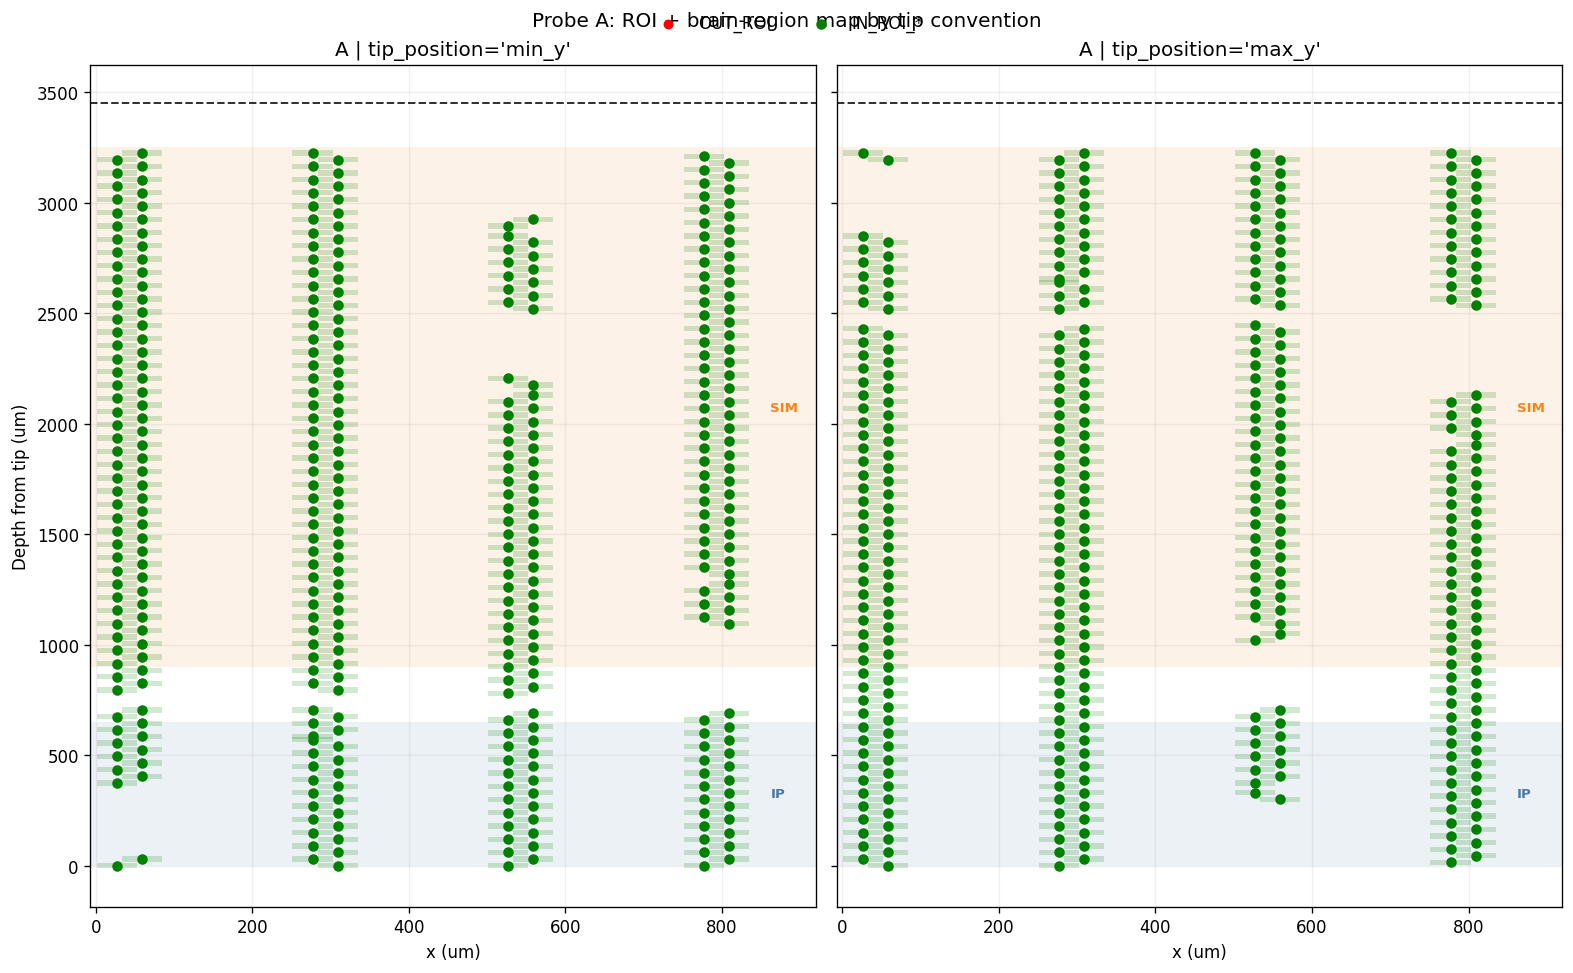

ROI depth (from tip): 3450.0 um
Brain-region depth bands from tip (um):
  IP: 0.0 -> 650.0
  SIM: 900.0 -> 3250.0
ROI labels (min_y):
  IN_ROI_IP: 79
  IN_ROI_SIM: 285
  IN_ROI_UNASSIGNED: 20
ROI labels (max_y):
  IN_ROI_IP: 78
  IN_ROI_SIM: 280
  IN_ROI_UNASSIGNED: 26
Shared IN_ROI channels: 384
Only IN when using min_y: 0
Only IN when using max_y: 0

=== B ===
Kilosort folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_B
channels: 383
unique x: 4, unique y: 192
median dx: 16.00 um
median dy: 20.00 um
median NN distance: 25.61 um
p90 NN distance: 25.61 um
Suggested nChannelsIsoDist: 6-8 (Moderately sparse geometry: consider increasing from default 4)


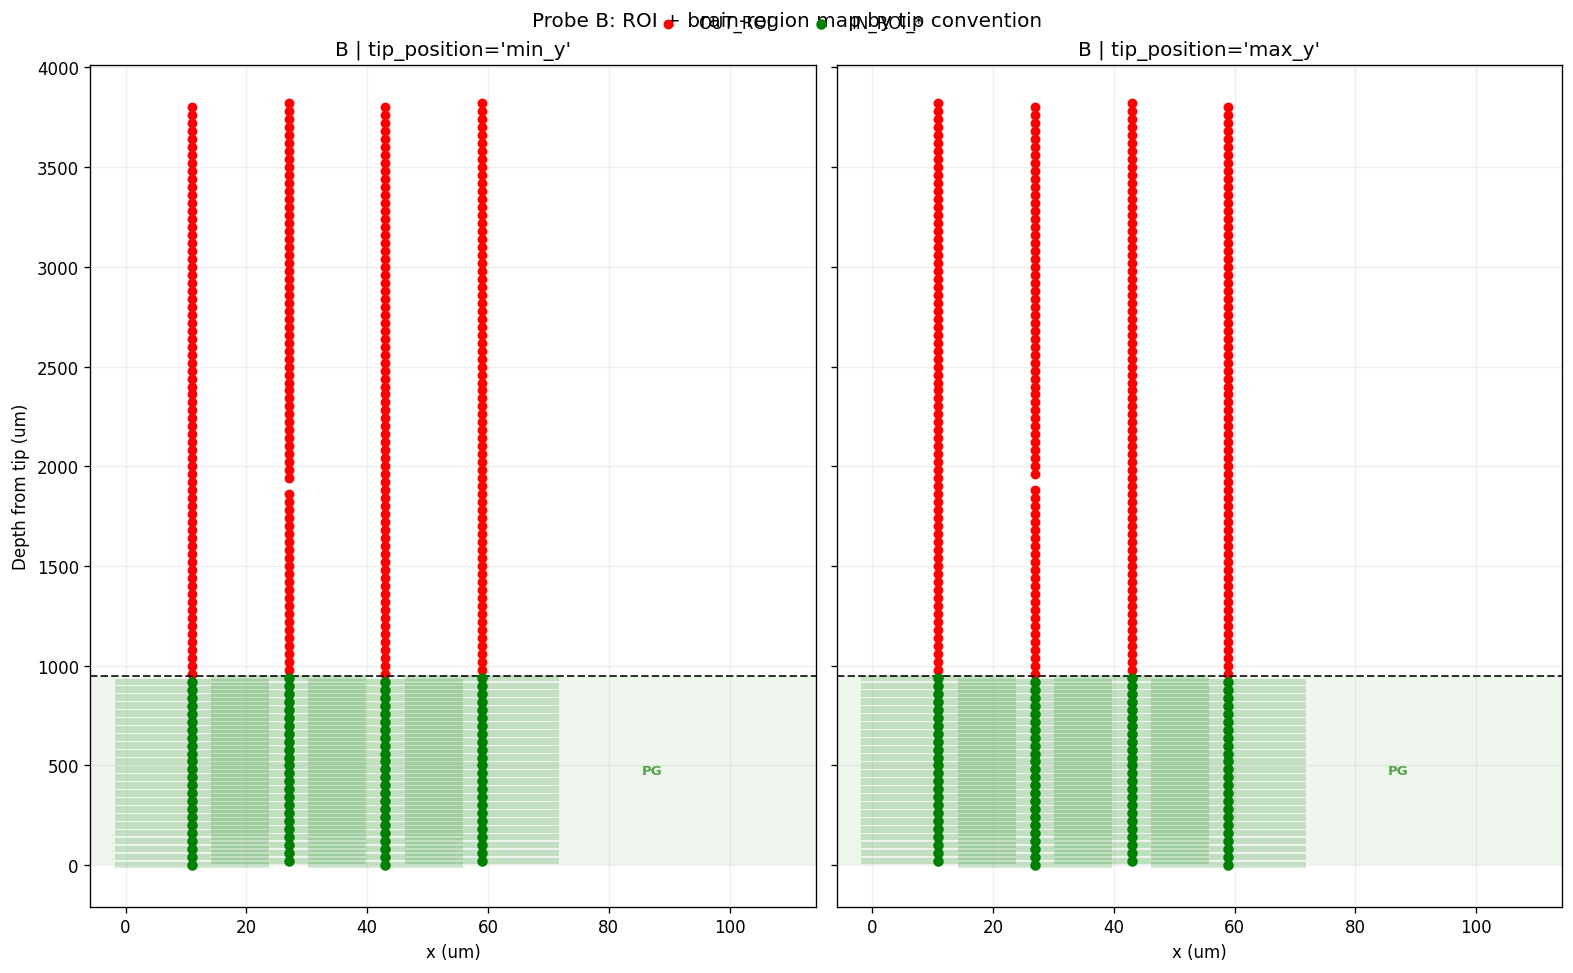

ROI depth (from tip): 950.0 um
Brain-region depth bands from tip (um):
  PG: 0.0 -> 950.0
ROI labels (min_y):
  IN_ROI_PG: 96
  OUT_ROI: 287
ROI labels (max_y):
  IN_ROI_PG: 96
  OUT_ROI: 287
Shared IN_ROI channels: 0
Only IN when using min_y: 96
Only IN when using max_y: 96

=== C ===
Kilosort folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_C
channels: 384
unique x: 8, unique y: 109
median dx: 32.00 um
median dy: 15.00 um
median NN distance: 30.00 um
p90 NN distance: 30.00 um
Suggested nChannelsIsoDist: 6-8 (Moderately sparse geometry: consider increasing from default 4)


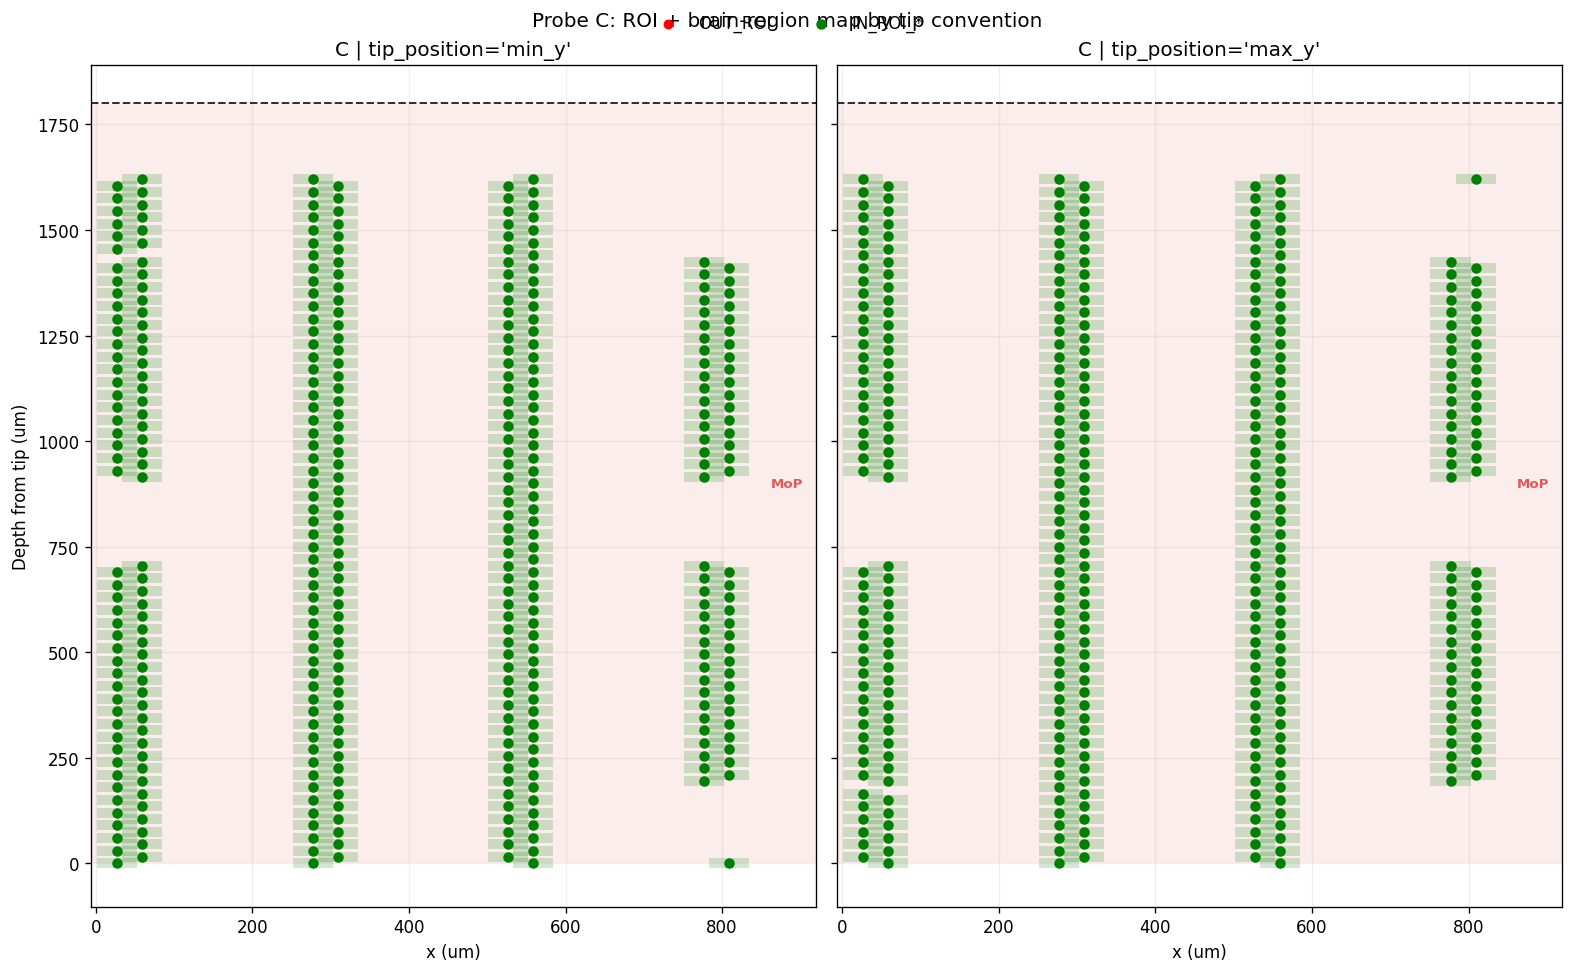

ROI depth (from tip): 1800.0 um
Brain-region depth bands from tip (um):
  MoP: 0.0 -> 1800.0
ROI labels (min_y):
  IN_ROI_MOP: 384
ROI labels (max_y):
  IN_ROI_MOP: 384
Shared IN_ROI channels: 384
Only IN when using min_y: 0
Only IN when using max_y: 0

=== D ===
Kilosort folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_D
channels: 384
unique x: 8, unique y: 78
median dx: 32.00 um
median dy: 15.00 um
median NN distance: 15.00 um
p90 NN distance: 15.00 um
Suggested nChannelsIsoDist: 4-6 (Dense geometry: default 4 is usually reasonable)


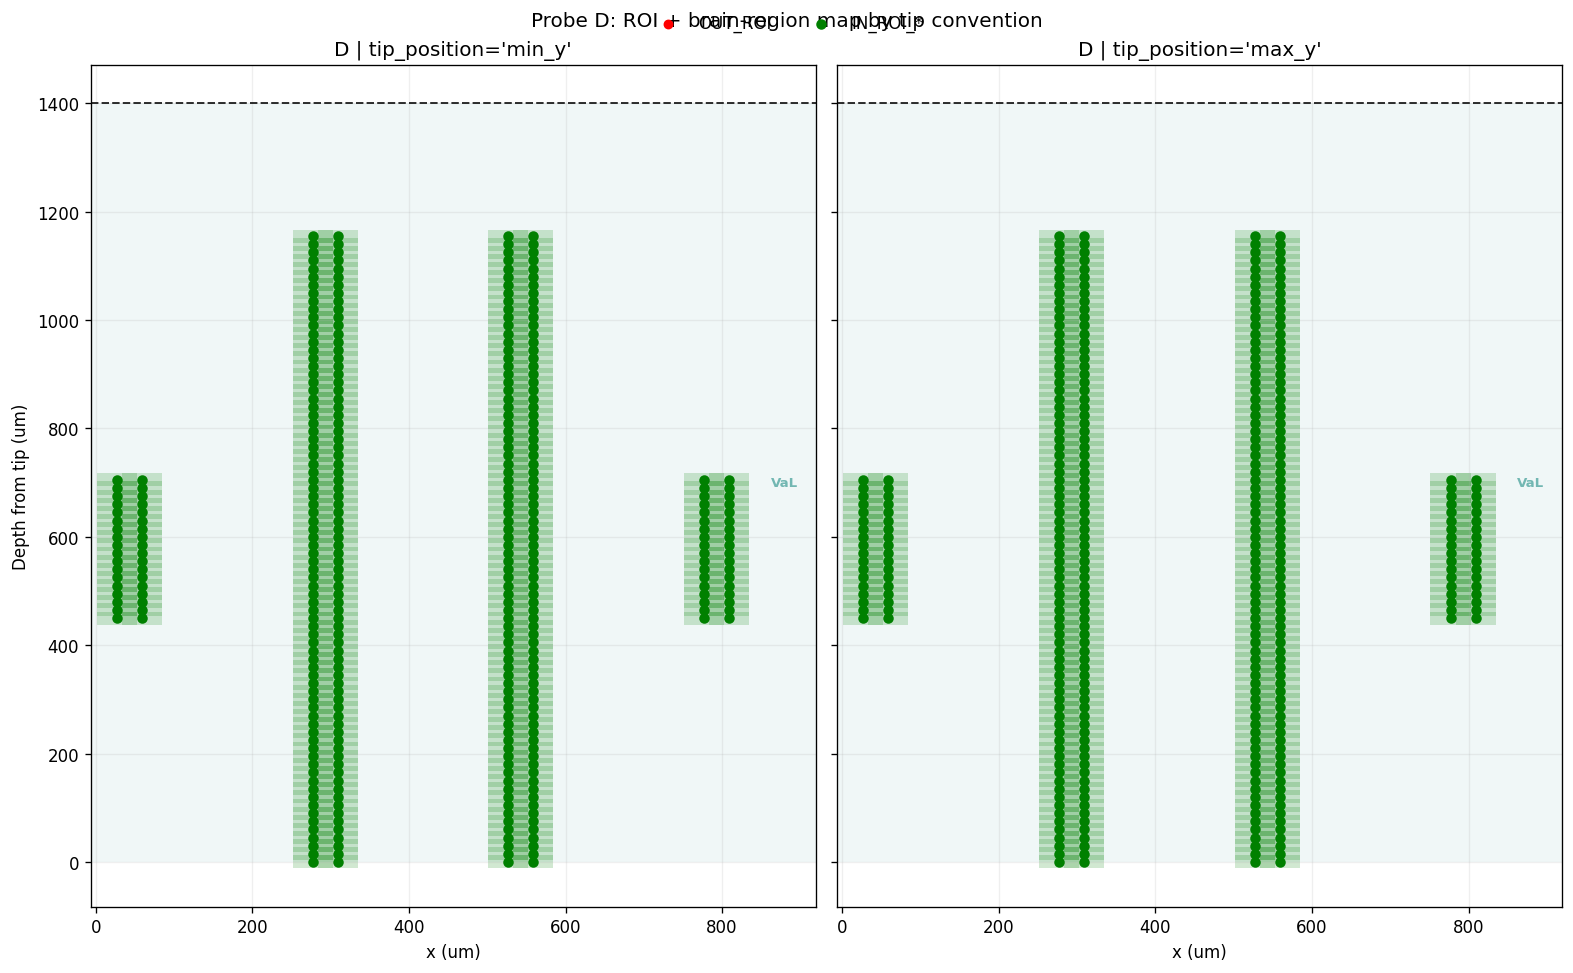

ROI depth (from tip): 1400.0 um
Brain-region depth bands from tip (um):
  VaL: 0.0 -> 1400.0
ROI labels (min_y):
  IN_ROI_VAL: 384
ROI labels (max_y):
  IN_ROI_VAL: 384
Shared IN_ROI channels: 384
Only IN when using min_y: 0
Only IN when using max_y: 0

=== E ===
Kilosort folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_E
channels: 383
unique x: 4, unique y: 192
median dx: 16.00 um
median dy: 20.00 um
median NN distance: 25.61 um
p90 NN distance: 25.61 um
Suggested nChannelsIsoDist: 6-8 (Moderately sparse geometry: consider increasing from default 4)


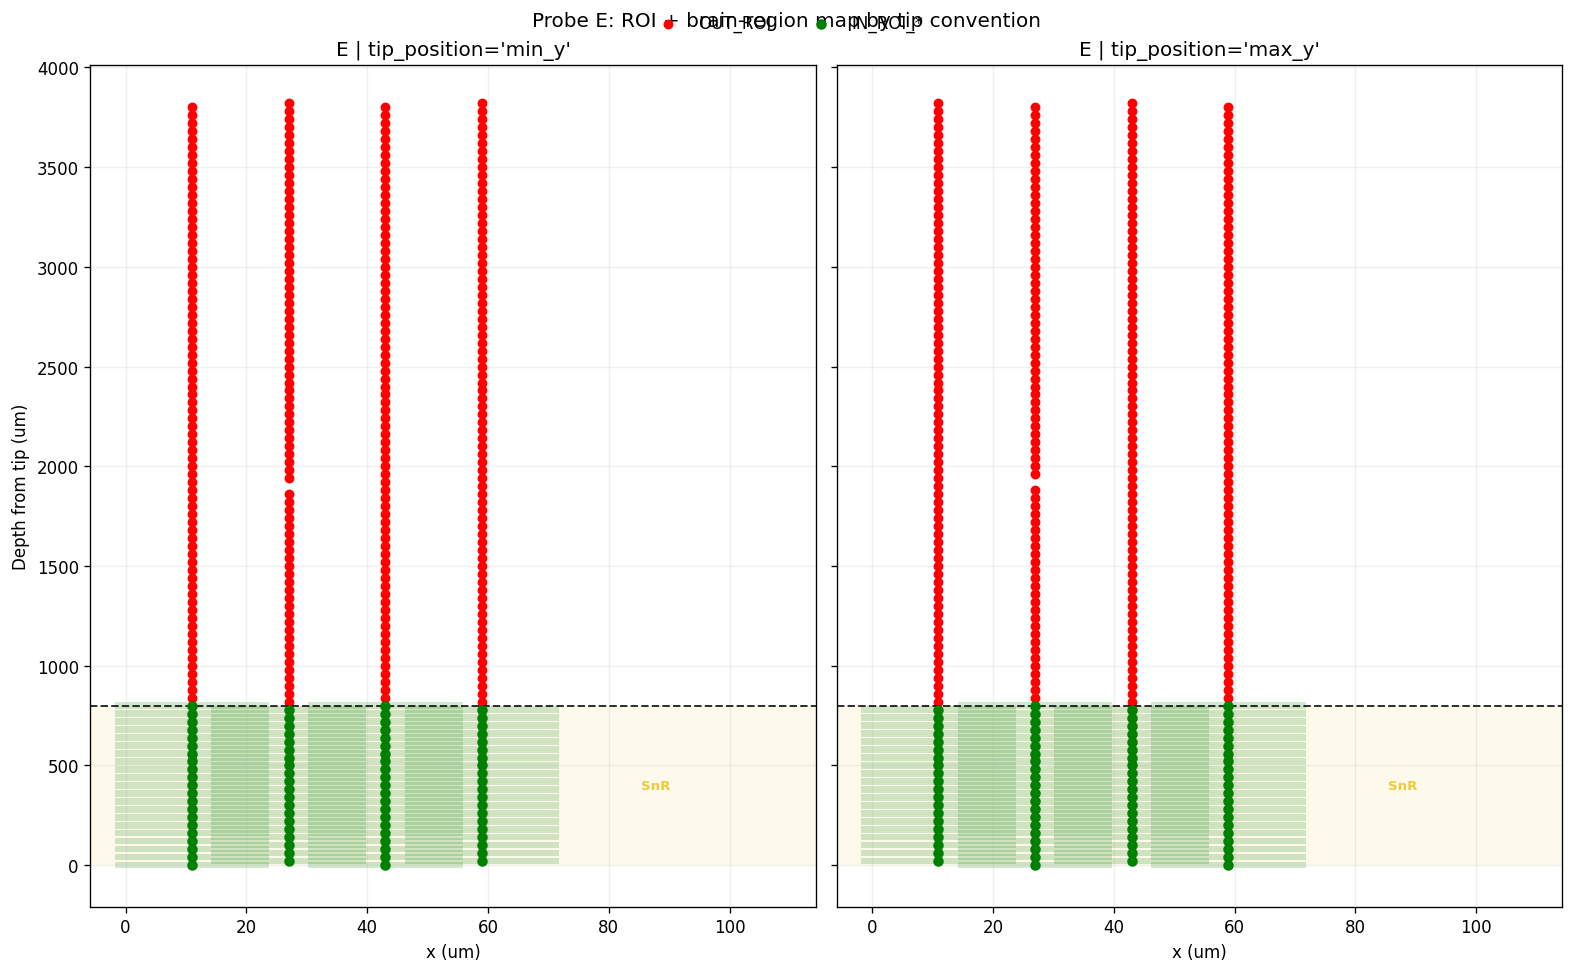

ROI depth (from tip): 800.0 um
Brain-region depth bands from tip (um):
  SnR: 0.0 -> 800.0
ROI labels (min_y):
  IN_ROI_SNR: 82
  OUT_ROI: 301
ROI labels (max_y):
  IN_ROI_SNR: 82
  OUT_ROI: 301
Shared IN_ROI channels: 0
Only IN when using min_y: 82
Only IN when using max_y: 82

=== F ===
Kilosort folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_F
channels: 383
unique x: 4, unique y: 192
median dx: 16.00 um
median dy: 20.00 um
median NN distance: 25.61 um
p90 NN distance: 25.61 um
Suggested nChannelsIsoDist: 6-8 (Moderately sparse geometry: consider increasing from default 4)


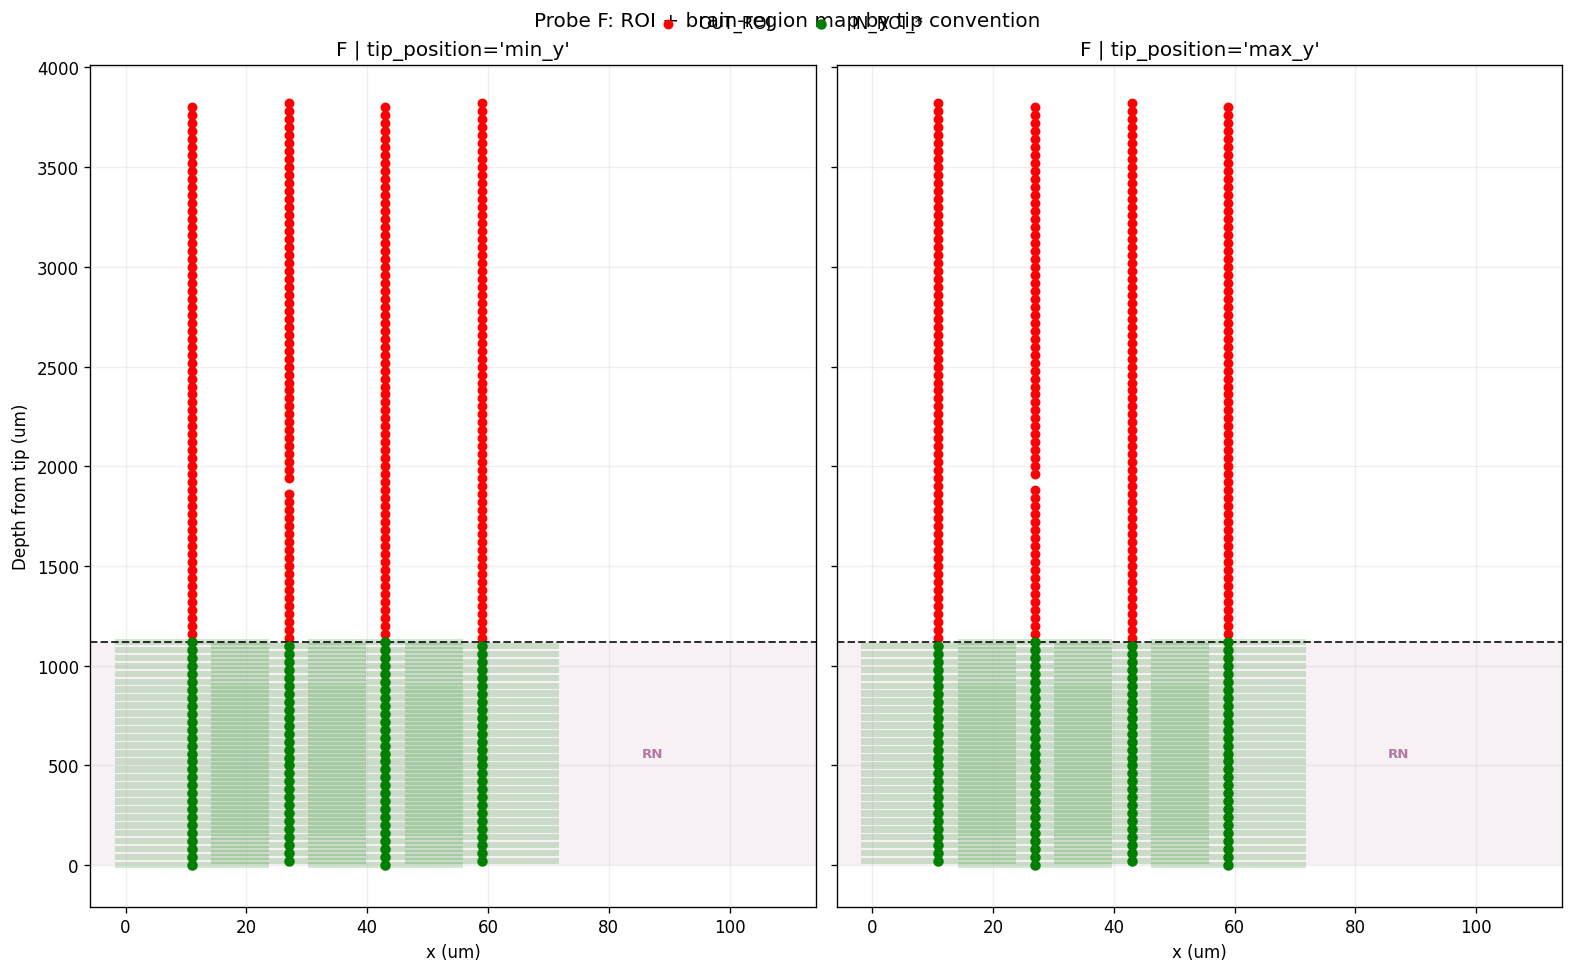

ROI depth (from tip): 1120.0 um
Brain-region depth bands from tip (um):
  RN: 0.0 -> 1120.0
ROI labels (min_y):
  IN_ROI_RN: 114
  OUT_ROI: 269
ROI labels (max_y):
  IN_ROI_RN: 114
  OUT_ROI: 269
Shared IN_ROI channels: 0
Only IN when using min_y: 114
Only IN when using max_y: 114


In [6]:
results = {}
probe_brain_regions = ctx.get("PROBE_BRAIN_REGIONS", {})
probe_recording_roi = ctx.get("PROBE_RECORDING_ROI", {})

for name, ks_dir in probe_dirs.items():
    print(f"\n=== {name} ===")
    if not (ks_dir / "channel_positions.npy").exists():
        print(f"Missing channel_positions.npy: {ks_dir}")
        continue

    channel_positions, channel_map = load_geometry(ks_dir)
    summary, nn = summarize_geometry(channel_positions)
    rec, note = suggest_nChannelsIsoDist(summary)

    results[name] = {
        "ks_dir": ks_dir,
        "summary": summary,
        "nChannelsIsoDist_recommendation": rec,
        "recommendation_note": note,
    }

    print(f"Kilosort folder: {ks_dir}")
    print(f"channels: {summary['n_channels']}")
    print(f"unique x: {summary['n_unique_x']}, unique y: {summary['n_unique_y']}")
    print(f"median dx: {summary['median_dx']:.2f} um")
    print(f"median dy: {summary['median_dy']:.2f} um")
    print(f"median NN distance: {summary['median_nn_dist']:.2f} um")
    print(f"p90 NN distance: {summary['p90_nn_dist']:.2f} um")
    print(f"Suggested nChannelsIsoDist: {rec} ({note})")

    roi_end_um = probe_recording_roi.get(name)
    if roi_end_um is None:
        print("No ROI depth configured for this probe, showing geometry only.")
        plot_geometry(channel_positions, title=f"{name}: channel_positions")
        continue

    roi_end_um = float(roi_end_um)
    details = plot_roi_channel_comparison(
        channel_positions,
        probe_letter=name,
        roi_end_um=roi_end_um,
        out_label="OUT_ROI",
        probe_brain_regions=probe_brain_regions,
    )

    min_info = details["min_y"]
    max_info = details["max_y"]
    min_mask = min_info["in_roi_mask"]
    max_mask = max_info["in_roi_mask"]

    shared_in = int(np.sum(min_mask & max_mask))
    only_min = int(np.sum(min_mask & ~max_mask))
    only_max = int(np.sum(max_mask & ~min_mask))

    print(f"ROI depth (from tip): {roi_end_um:.1f} um")
    print("Brain-region depth bands from tip (um):")
    for band in max_info["region_bands"]:
        print(f"  {band['region']}: {float(band['start_um']):.1f} -> {float(band['end_um']):.1f}")

    for tip_position, info in (("min_y", min_info), ("max_y", max_info)):
        counts = pd.Series(info["roi_labels"]).value_counts().sort_index()
        print(f"ROI labels ({tip_position}):")
        for label, count in counts.items():
            print(f"  {label}: {int(count)}")

    print(f"Shared IN_ROI channels: {shared_in}")
    print(f"Only IN when using min_y: {only_min}")
    print(f"Only IN when using max_y: {only_max}")

    region_bands_text = ", ".join(
        [f"{b['region']}[{float(b['start_um']):.0f}-{float(b['end_um']):.0f}]" for b in max_info["region_bands"]]
    )

    results[name].update(
        {
            "roi_end_um": roi_end_um,
            "region_bands_um": region_bands_text,
            "in_channels_min_y": int(np.sum(min_mask)),
            "in_channels_max_y": int(np.sum(max_mask)),
            "in_channels_shared": shared_in,
            "in_channels_only_min_y": only_min,
            "in_channels_only_max_y": only_max,
        }
    )

## 4) Optional: quick comparison table

In [7]:
try:
    import pandas as pd
    rows = []
    for name, info in results.items():
        row = {
            "probe": name,
            **info["summary"],
            "nChannelsIsoDist_recommendation": info["nChannelsIsoDist_recommendation"],
            "note": info["recommendation_note"],
            "roi_end_um": info.get("roi_end_um", np.nan),
            "region_bands_um": info.get("region_bands_um", ""),
            "in_channels_min_y": info.get("in_channels_min_y", np.nan),
            "in_channels_max_y": info.get("in_channels_max_y", np.nan),
            "in_channels_shared": info.get("in_channels_shared", np.nan),
            "in_channels_only_min_y": info.get("in_channels_only_min_y", np.nan),
            "in_channels_only_max_y": info.get("in_channels_only_max_y", np.nan),
        }
        rows.append(row)
    display(pd.DataFrame(rows).sort_values("probe"))
except Exception as e:
    print("Pandas table skipped:", e)

,probe,n_channels,n_unique_x,n_unique_y,median_dx,median_dy,median_nn_dist,p90_nn_dist,nChannelsIsoDist_recommendation,note,roi_end_um,region_bands_um,in_channels_min_y,in_channels_max_y,in_channels_shared,in_channels_only_min_y,in_channels_only_max_y
0,A,384,8,200,32.0,15.0,43.863424,43.863424,8-12,Sparse/interleaved geometry: use more nearby c...,3450.0,"IP[0-650], SIM[900-3250]",384,384,384,0,0
1,B,383,4,192,16.0,20.0,25.612497,25.612497,6-8,Moderately sparse geometry: consider increasin...,950.0,PG[0-950],96,96,0,96,96
2,C,384,8,109,32.0,15.0,30.000000,30.000000,6-8,Moderately sparse geometry: consider increasin...,1800.0,MoP[0-1800],384,384,384,0,0
3,D,384,8,78,32.0,15.0,15.000000,15.000000,4-6,Dense geometry: default 4 is usually reasonable,1400.0,VaL[0-1400],384,384,384,0,0
4,E,383,4,192,16.0,20.0,25.612497,25.612497,6-8,Moderately sparse geometry: consider increasin...,800.0,SnR[0-800],82,82,0,82,82
5,F,383,4,192,16.0,20.0,25.612497,25.612497,6-8,Moderately sparse geometry: consider increasin...,1120.0,RN[0-1120],114,114,0,114,114


## How to interpret for your specific NP2 patterns

Given your description:
- **Probe A** (`ON,OFF,OFF,OFF` interleaving): likely sparsest effective local neighborhood â†’ start around **8** (test 8â€“12).
- **Probe C** (`ON,OFF` interleaving): moderate sparsity â†’ start around **6** (test 6â€“8).
- **Probe D** (contiguous ON region): densest local neighborhood â†’ default **4** is usually acceptable (test 4â€“6).

Use the printed spacing stats and a small-unit QC comparison to decide final values.
